### Modelo de regresión logística ordinal

In [19]:
# Importamos el DF con los datos de ausentismo y los niveles categóricos.

import pandas as pd

df = pd.read_csv(r"C:\Users\jprom\Desktop\Projecte\ProjecteData\Equip_20\Data\DF_integrado_modelo.csv")
df_modelo = df.copy()
df_modelo.head()


,id,reason_id,absence_reason,justified,Absenteeism_hours,Month_absence_num,Month_absence,Day_week,Day_of_week,Season,...,weight,height,bmi,Group,distance_categories,Absence_type,ID,work_days_absent,ab_level,level
0,14,11,Diseases of the digestive system,1,120,11,November,2,Monday,Spring,...,95,196,25,26-35,entre 10 y 20 km,Justified,14,105.50,4,Muy alto
1,36,13,Diseases of the musculoskeletal system and con...,1,120,4,April,4,Wednesday,Winter,...,98,178,31,46-54,entre 10 y 20 km,Justified,36,78.88,4,Muy alto
2,9,6,Diseases of the nervous system,1,120,7,July,3,Tuesday,Summer,...,65,172,22,55-65,entre 10 y 20 km,Justified,9,90.75,4,Muy alto
3,28,9,Diseases of the circulatory system,1,112,7,July,3,Tuesday,Summer,...,69,169,24,26-35,entre 21 y 30 km,Justified,28,71.38,4,Muy alto
4,9,12,Diseases of the skin and subcutaneous tissue,1,112,3,March,3,Tuesday,Autumn,...,65,172,22,55-65,entre 10 y 20 km,Justified,9,90.75,4,Muy alto


#### Tabla de frecuencia univariada

In [18]:
# Tabla frecuencia de ausencias por nivel de absentismo

frecuencia_absoluta = df_modelo['level'].value_counts()
frecuencia_relativa = frecuencia_absoluta / len(df_modelo['level'])
frecuencia_relativa_porcentual = (frecuencia_relativa * 100).round(2)
frecuencia_relativa_acumulada = frecuencia_relativa.cumsum()

Tabla_frecuencias = pd.DataFrame({'Frecuencia absoluta':frecuencia_absoluta,'Frecuencia relativa': frecuencia_relativa,
                                'Frecuencia relativa %': frecuencia_relativa_porcentual,
                    'Frecuencia relativa acumulada': frecuencia_relativa_acumulada})
Tabla_frecuencias

,Frecuencia absoluta,Frecuencia relativa,Frecuencia relativa %,Frecuencia relativa acumulada
level,,,,
Muy alto,414,0.466742,46.67,0.466742
Bajo,197,0.222097,22.21,0.688839
Alto,154,0.173619,17.36,0.862458
Medio,122,0.137542,13.75,1.000000


#### Tablas de frecuencias bivariadas

In [15]:
tabla_frecuencias1= pd.crosstab(df_modelo['level'], df_modelo['Social_smoker'], normalize=True).round(2)*100
tabla_frecuencias1.loc['Total'] = tabla_frecuencias1.sum(axis=0)
tabla_frecuencias1

Social_smoker,0,1
level,,
Alto,17.0,0.0
Bajo,18.0,4.0
Medio,11.0,3.0
Muy alto,47.0,0.0
Total,93.0,7.0


In [16]:
tabla_frecuencias2 = pd.crosstab(df_modelo['level'], df_modelo['Social_drinker'], normalize=True).round(2)*100
tabla_frecuencias2.loc['Total'] = tabla_frecuencias2.sum(axis=0)
tabla_frecuencias2

Social_drinker,0,1
level,,
Alto,5.0,12.0
Bajo,10.0,12.0
Medio,11.0,3.0
Muy alto,17.0,30.0
Total,43.0,57.0


In [17]:
tabla_frecuencias3 = pd.crosstab(df_modelo['level'], df_modelo['disciplined'], normalize=True).round(2)*100
tabla_frecuencias3.loc['Total'] = tabla_frecuencias3.sum(axis=0)
tabla_frecuencias3

disciplined,0,1
level,,
Alto,17.0,1.0
Bajo,21.0,1.0
Medio,13.0,1.0
Muy alto,45.0,1.0
Total,96.0,4.0


### Construcción del modelo en Scikit-learn

In [21]:
# Dividir las columnas a analizar en dos tipos de variables: dependiente (o variable objetivo) e independiente (o variables características).

variables_indep = ['Social_smoker', 'Social_drinker', 'disciplined', 'id', 'work_days_absent']
X = df_modelo[variables_indep]
y = df_modelo.ab_level

In [22]:
# Dividir el conjunto de datos en un conjunto de entrenamiento y un conjunto de prueba

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=16)

#### Verificar y escalar los datos
El solucionador L-BFGS, al igual que muchos algoritmos de optimización, funciona mucho mejor cuando todas las características tienen una escala similar. Esta es una causa muy común de problemas de convergencia.

In [29]:
# Importar el módulo Regresión logística y crea un objeto clasificador de Regresión logística
#  utilizando la función LogisticRegression() con random_state para la reproducibilidad.

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

"""
# Increase the limit to 1000 or a larger number
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)
"""

# Create a pipeline to scale data and fit the model
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(solver='lbfgs', max_iter=100)) # max_iter 100 might work after scaling
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

#### Evaluación del modelo mediante la matriz de confusión

Una matriz de confusión es una tabla que se utiliza para evaluar el rendimiento de un modelo de clasificación. Lo fundamental de una matriz de confusión es el número de predicciones correctas e incorrectas sumadas por clases.

In [30]:
# import the metrics class
from sklearn import metrics

cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

array([[ 48,   0,   0,   0],
       [  0,  20,   1,   0],
       [  0,   0,  38,   0],
       [  0,   0,   0, 115]])

#### Visualización de la matriz de confusión mediante un mapa de calor


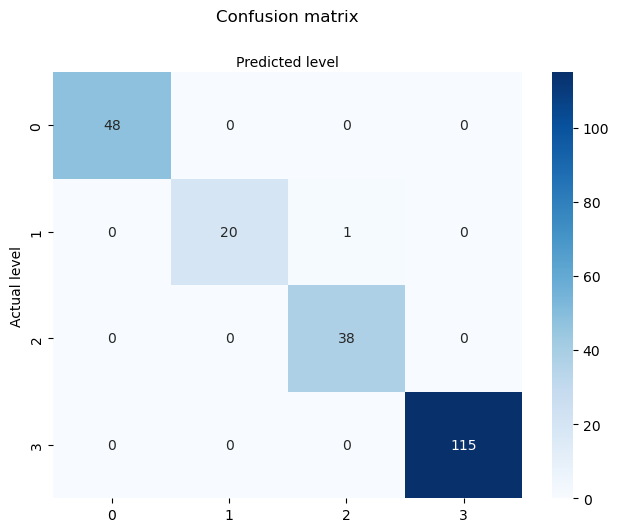

In [36]:
# import required modules
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Use class names derived from the confusion matrix size and convert to strings
# (strings satisfy plt.xticks type hints)
class_names = [str(i) for i in range(cnf_matrix.shape[0])]
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="Blues", fmt='g', ax=ax)
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual level')
plt.xlabel('Predicted level');

#### Métricas de evaluación de la matriz de confusión


In [38]:
# Evaluar el modelo utilizando classification_report para ver la exactitud, la precisión y la recuperación.

from sklearn.metrics import classification_report
target_names = ['Bajo', 'Medio', 'Alto', 'Muy Alto']
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

        Bajo       1.00      1.00      1.00        48
       Medio       1.00      0.95      0.98        21
        Alto       0.97      1.00      0.99        38
    Muy Alto       1.00      1.00      1.00       115

    accuracy                           1.00       222
   macro avg       0.99      0.99      0.99       222
weighted avg       1.00      1.00      1.00       222

